# Multiple Type Experiment

In [43]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
# import plotly.express
# import plotly.express as px
import pandas as pd
import cvxpy as cp
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
def generate_cvxpy_solve(num_types, num_resources):
    x = cp.Variable(shape=(num_types,num_resources))

    sizes = cp.Parameter(num_types, nonneg=True)
    weights = cp.Parameter((num_types, num_resources), nonneg=True)
    budget = cp.Parameter(num_resources, nonneg=True)


    objective = cp.Maximize(cp.log(cp.sum(cp.multiply(x, weights), axis=1)) @ sizes)


    constraints = []
    constraints += [0 <= x]
    for i in range(num_resources):
        constraints += [x[:, i] @ sizes <= budget[i]]
    # constraints += [x @ sizes <= budget]

    prob = cp.Problem(objective, constraints)
    
    def solver(true_sizes, true_weights, true_budget):
        sizes.value = true_sizes
        weights.value = true_weights
        budget.value = true_budget
        
        prob.solve()
        
        return prob.value, np.around(x.value, 5)
    
    return prob, solver

In [45]:
prob, solver = generate_cvxpy_solve(2, 2)

solver(np.asarray([1., 1.]), np.asarray([[1,1],[1,1]]), np.asarray([1,1]))

(2.9030394753597835e-10,
 array([[0.5, 0.5],
        [0.5, 0.5]]))

In [46]:
prob, solver = generate_cvxpy_solve(5,3)

### Sensitivity of EG Program

Calculating difference in allocations for: 0.0
Sizes: ([1.0, 1.0], [1.0, 1.0], [1.0, 1.0])
Solutions: (array([[2., 0.],
       [0., 2.]]), array([[2., 0.],
       [0., 2.]]), array([[2., 0.],
       [0., 2.]]))
Objective Values: (2.4371159792482775, 2.4371159792482775, 2.4371159792482775)
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.05
Sizes: ([1.0, 1.0], [0.95, 0.95], [1.05, 1.05])
Solutions: (array([[2., 0.],
       [0., 2.]]), array([[2.105, 0.   ],
       [0.   , 2.105]]), array([[1.905, 0.   ],
       [0.   , 1.905]]))
Objective Values: (2.4371159792482775, 2.4127174264157087, 2.456512432910465)
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.1
Sizes: ([1.0, 1.0], [0.9, 0.9], [1.1, 1.1])
Solutions: (array([[2., 0.],
       [0., 2.]]), a

       [0.   , 1.026]]))
Objective Values: (2.4371159792482775, 0.42142891076433575, 2.1478416247849674)
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95] [ 0.     0.105  0.222  0.353  0.5    0.667  0.857  1.077  1.333  1.636
  2.     2.444  3.     3.714  4.667  6.     8.    11.333 18.    38.   ] [0.    0.095 0.182 0.261 0.333 0.4   0.462 0.519 0.571 0.621 0.667 0.71
 0.75  0.788 0.824 0.857 0.889 0.919 0.947 0.974]


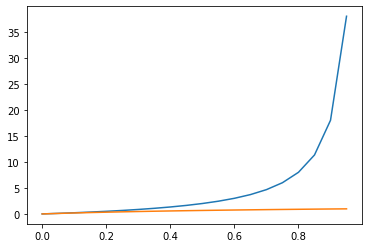

In [211]:
eps = 0.05

delta_list = np.arange(0, 1, eps)
y1 = np.zeros(len(delta_list))
y2 = np.zeros(len(delta_list))

prob, solver = generate_cvxpy_solve(2, 2)
true_weights = np.asarray([[1.1, .4],[1.3, 2.6]])
true_budget = [2., 2.]


index = 0
for delta in delta_list:
    print('Calculating difference in allocations for: ' + str(delta))
    sizes_1 = [1., 1.]
    sizes_2 = [1-delta, 1-delta]
    sizes_3 = [1+delta, 1+delta]
    
    print('Sizes: ' + str((sizes_1, sizes_2, sizes_3)))
          
    v1, x_1 = solver(sizes_1, true_weights, true_budget)
    v2, x_2 = solver(sizes_2, true_weights, true_budget)
    v3, x_3 = solver(sizes_3, true_weights, true_budget)
    
    x_1 = np.around(x_1, 3)
    x_2 = np.around(x_2, 3)
    x_3 = np.around(x_3, 3)
    
    print('Solutions: ' + str((x_1, x_2, x_3)))
    print('Objective Values: ' + str((v1, v2, v3)))
    
    print('Testing Budget Constraint: ')
    print(sizes_1 @ x_1 <= true_budget)
    
    print('Testing Monotonicity:')
    print(x_1 <= x_2)
    print(x_1 >= x_3)
    y1[index] = np.max(np.abs(x_1 - x_2))
    y2[index] = np.max(np.abs(x_1 - x_3))
    index += 1
    
print(delta_list, y1, y2)
plt.plot(delta_list, y1)
plt.plot(delta_list, y2)

### Offline Optimal Solution

In [75]:
def offline_opt(budget, size, mean, weights, solver):
    tot_size = np.sum(size, axis=0)
    _, x = solver(tot_size, weights, budget)
    allocation = np.zeros((size.shape[0], weights.shape[0], weights.shape[1]))
    for i in range(size.shape[0]):
        allocation[i,:,:] = x
    return allocation

### Threshold Based Algorithms

In [287]:
def fixed_threshold(budget, size, mean, weights, solver):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


    tot_mean_size = np.sum(mean, axis=0) + 7*np.sqrt(num_locations * np.log(num_locations))
    _, lower_thresh = solver(tot_mean_size, weights, budget)


    for i in range(n):

        if np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
            allocation[i,:,:] = lower_thresh
        else:
            print('Out of budget!')
            allocation[i, :, :] = np.array([budget_remaining / np.sum(size[i,:]),]*num_types)

        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    
    return allocation, budget_remaining

In [54]:
def sid_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    c = 1
    conf_bnd = (np.sum(mean[1:]))**(0.6) #c*np.sqrt(np.sum(mean)* np.log(len(size)-1)) 

    thresh_lower = budget / (size[0] + np.sum(mean[1:]) + conf_bnd)
    thresh_upper = budget / (size[0] + np.sum(mean[1:]) - conf_bnd)

    for i in range(len(allocation)-1):
        # TODO: add on confidence terms for (T - i) people here
        #rem = len(allocation) - (i + 1)
        budget_upper = thresh_upper*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))
        budget_lower = thresh_lower*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))
        gam = (budget_remaining - budget_lower) / (budget_upper - budget_lower)
        
        if gam >= 0.95: allocation[i] = thresh_upper
        else: allocation[i] = thresh_lower
        
        if allocation[i] * size[i] <= budget_remaining:
            budget_remaining -= allocation[i] * size[i]
        else:
            allocation[i] = budget_remaining/size[i]
            print('Out of budget!')
            budget_remaining = 0

        if budget_remaining < 0:
            print("Error: Negative Budget")

            
    # fix for last agent
    allocation[-1] = min(thresh_upper, budget_remaining / size[-1])
    
    return allocation, bud



In [57]:
def adapt_init_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    
    c = 0.7
    rem = len(allocation)
    conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem)))     
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')

            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [ ]:
def adapt_init_under_over_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    
    c = 0.7
    rem = len(allocation)
    conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem)))     
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining <= thresh_upper * (np.sum(mean[i+1:]) + conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_lower

        else:
            allocation[i] = thresh_upper

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [ ]:
def adapt_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    
    c = 0.7

    rem = len(allocation)
    conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem))) 


    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):
    
    
        rem = len(allocation) - i
        conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem))) 
        # calculates initial thresholds
        thresh_lower = budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:]) + conf_bnd)
        thresh_upper = budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:]) - conf_bnd)      
        

        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation

In [ ]:
def adapt_init_threshold_new_cb(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    
    c = 0.7
    rem = len(allocation)
    conf_bnd = c*np.sqrt(np.mean(mean)*(rem* np.log(rem))) 

    # calculates initial thresholds
    thresh_lower = budget / (np.sum(size[0]) + np.sum(mean[1:]) + conf_bnd)
    thresh_upper = budget / (np.sum(size[0]) + np.sum(mean[1:]) - conf_bnd)  
    # print(thresh_lower, thresh_upper)
    
    for i in range(len(allocation)):   
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        elif budget_remaining >= thresh_lower * (size[0] + np.sum(mean[1:]) + - np.sum(size[0:i+1]) + conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



### Scaling with n

In [17]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([3, 2, 1, 4, 4])

In [288]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])

# algo_list = [adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, adapt_init_under_over_threshold, fixed_threshold]
algo_list = [fixed_threshold]

num_iterations = 20
max_n = 100

mean_size = np.asarray([1, 3, 6, 2, 5])

for n in tqdm(np.arange(2,max_n+1)):
    print('Num Locations: ' + str(n))
    # pected_size = mean_size
    budget = [n, n, n]
    
    mean = np.array([mean_size,]*n)
    # print(mean)
    for i in range(num_iterations):
        # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
        size = 1+np.random.poisson(size=(n, num_types), lam = mean_size)
        # print('Size: ' + str(size))
        total_num_types = np.sum(size, axis=0)
        
        prob, solver = generate_cvxpy_solve(num_types, num_resources)

        
        # print(num_types, num_resources, budget.shape size.shape, )
        
        opt = offline_opt(budget, size, mean, weights, solver)
        
        # print('opt: ' + str(opt))
        for algo in algo_list:
            sol, waste = algo(budget, size, mean, weights, solver)
            
            # print('Algo: ' + str(sol))
            # print('Opt: ' + str(opt))
            
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Waste', 'Value': np.max(waste)}
            data.append(data_dict)
        
    sleep(0)

  0%|          | 0/99 [00:00<?, ?it/s]

Num Locations: 2
Num Locations: 3
Num Locations: 4
Num Locations: 5
Out of budget!
Num Locations: 6
Num Locations: 7
Num Locations: 8
Num Locations: 9
Num Locations: 10
Num Locations: 11
Num Locations: 12
Num Locations: 13
Num Locations: 14
Num Locations: 15
Num Locations: 16
Num Locations: 17
Num Locations: 18
Num Locations: 19
Num Locations: 20
Num Locations: 21
Num Locations: 22
Num Locations: 23
Num Locations: 24
Num Locations: 25
Num Locations: 26
Num Locations: 27
Num Locations: 28
Num Locations: 29
Num Locations: 30
Out of budget!
Num Locations: 31
Num Locations: 32
Num Locations: 33
Num Locations: 34
Num Locations: 35
Num Locations: 36
Num Locations: 37
Num Locations: 38
Num Locations: 39
Num Locations: 40
Num Locations: 41
Num Locations: 42
Num Locations: 43
Num Locations: 44
Num Locations: 45
Out of budget!
Num Locations: 46
Num Locations: 47
Num Locations: 48
Num Locations: 49
Num Locations: 50
Num Locations: 51
Num Locations: 52
Num Locations: 53
Num Locations: 54
Num Locat

<AxesSubplot:title={'center':'Simple Distribution Waste'}, xlabel='NumGroups', ylabel='Value'>

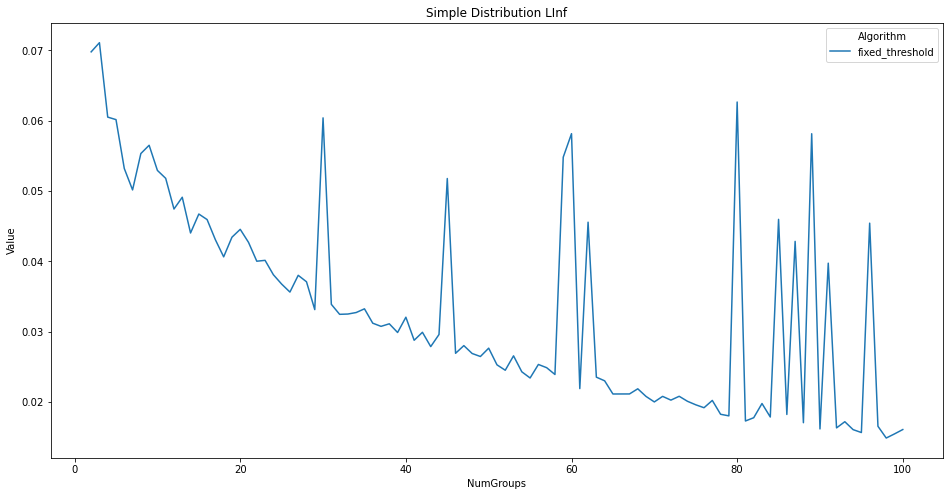

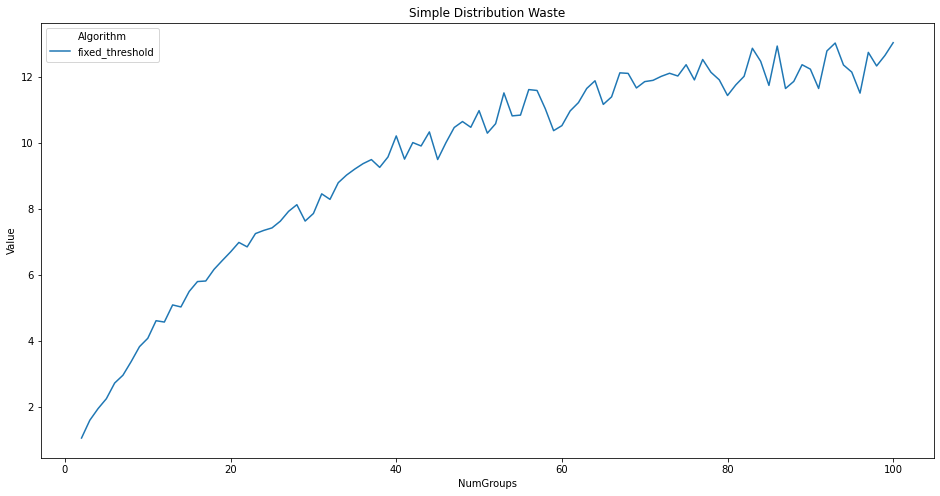

In [289]:
df = pd.DataFrame.from_records(data)
df.columns


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Linf'], ci=None)


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Waste'], ci=None)


In [258]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])

# algo_list = [adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, adapt_init_under_over_threshold, fixed_threshold]
algo_list = [fixed_threshold]

num_iterations = 20
max_n = 100

mean_size = np.asarray([1, 3, 6, 2, 5])

n = 6
print('Num Locations: ' + str(n))
# pected_size = mean_size
budget = [n, n, n]
print(budget)
mean = np.array([mean_size,]*n)
    # print(mean)
        # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
size = 1+np.random.poisson(size=(n, num_types), lam = mean_size)
        # print('Size: ' + str(size))
total_num_types = np.sum(size, axis=0)
        
prob, solver = generate_cvxpy_solve(num_types, num_resources)

        
        # print(num_types, num_resources, budget.shape size.shape, )
        
opt = offline_opt(budget, size, mean, weights, solver)
print(opt[0,:,:])

waste = np.zeros(num_resources)
print('Offline Waste')

print(opt[:,:,0].shape)
print(size.shape)
print(np.sum(np.multiply(size, opt[:,:,0])))

sol, waste = fixed_threshold(budget, size, mean, weights, solver)
print(np.sum(np.multiply(size, sol[:,:,0])))
print(waste)

Num Locations: 6
[6, 6, 6]
[[ 0.       0.       0.14118]
 [ 0.       0.10084  0.     ]
 [ 0.15    -0.       0.02118]
 [ 0.       0.10084  0.     ]
 [ 0.       0.03866  0.08706]]
Offline Waste
(6, 5)
(6, 5)
6.0
4.5808
[1.4192  1.5684  1.67502]


In [268]:
   
allocation = np.zeros((n, num_types, num_resources))
    
    
budget_remaining = budget


tot_mean_size = np.sum(mean, axis=0) + 1*np.sqrt(n * np.log(n))

_, lower_thresh = solver(tot_mean_size, weights, budget)
  
print(lower_thresh)

for i in range(n):
    
    if np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
        allocation[i,:,:] = lower_thresh
    else:
        print('out of budget: ' + str(i))
        print(budget_remaining)
        
        allocation[i, :, :] = np.array([budget_remaining / np.sum(size[i,:]),]*num_types)
                
    budget_remaining -= np.matmul(size[i, :], allocation[i])

    
print(allocation)
print(budget_remaining)
#     # print(lower_thresh)
#     # print(lower_thresh.shape)
    
    
    
#     for i in range(num_locations):
#         # ensures you can't run out of budget
        
#         if np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
#             allocation[i,:,:] = lower_thresh
#         else:
#             for j in range(num_types):
#                 for k in range(num_resources):
#                     allocation[i,j,k] = budget_remaining[k] / size[i,j]
#             budget_remaining -= np.matmul(size[i,:], allocation[i])
#             return allocation, budget_remaining
#         # int('Printing allocation and size shape')
#         # int(allocation[i, :, :].shape)  # 5 by 3
#         # int(size[i,:].shape)   # 5 by 1
#         # int('Done')
#         budget_remaining -= np.matmul(size[i, :], allocation[i]) 
    
    
#     return allocation, budget_remaining

[[ 0.       0.       0.16217]
 [ 0.       0.11584  0.     ]
 [ 0.15275 -0.       0.03997]
 [ 0.       0.11584  0.     ]
 [ 0.       0.05305  0.08791]]
out of budget: 4
[1.4175  1.23212 1.25883]
out of budget: 5
[0. 0. 0.]
[[[ 0.          0.          0.16217   ]
  [ 0.          0.11584     0.        ]
  [ 0.15275    -0.          0.03997   ]
  [ 0.          0.11584     0.        ]
  [ 0.          0.05305     0.08791   ]]

 [[ 0.          0.          0.16217   ]
  [ 0.          0.11584     0.        ]
  [ 0.15275    -0.          0.03997   ]
  [ 0.          0.11584     0.        ]
  [ 0.          0.05305     0.08791   ]]

 [[ 0.          0.          0.16217   ]
  [ 0.          0.11584     0.        ]
  [ 0.15275    -0.          0.03997   ]
  [ 0.          0.11584     0.        ]
  [ 0.          0.05305     0.08791   ]]

 [[ 0.          0.          0.16217   ]
  [ 0.          0.11584     0.        ]
  [ 0.15275    -0.          0.03997   ]
  [ 0.          0.11584     0.        ]
  [ 0.      

In [ ]:
df = pd.DataFrame.from_records(data)
df.columns


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Linf'], ci=None)


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Waste'], ci=None)


### Group by Group Difference

In [ ]:
data = []

n = 100
num_iterations = 100

mean_size = 1.5
expected_size = np.zeros(n) + mean_size

for i in tqdm(range(num_iterations)):
    
    expected_size = np.zeros(n) + mean_size
    budget = n
    size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    
    opt = offline_opt(budget, size, expected_size)
    for algo in algo_list:
        sol = algo(budget, size, expected_size)
        for i in range(n):
            data.append({'Location':i, 'Algorithm':algo.__name__, 'Value': opt[i] - sol[i]})
            
    for i in range(n):
        data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

[]

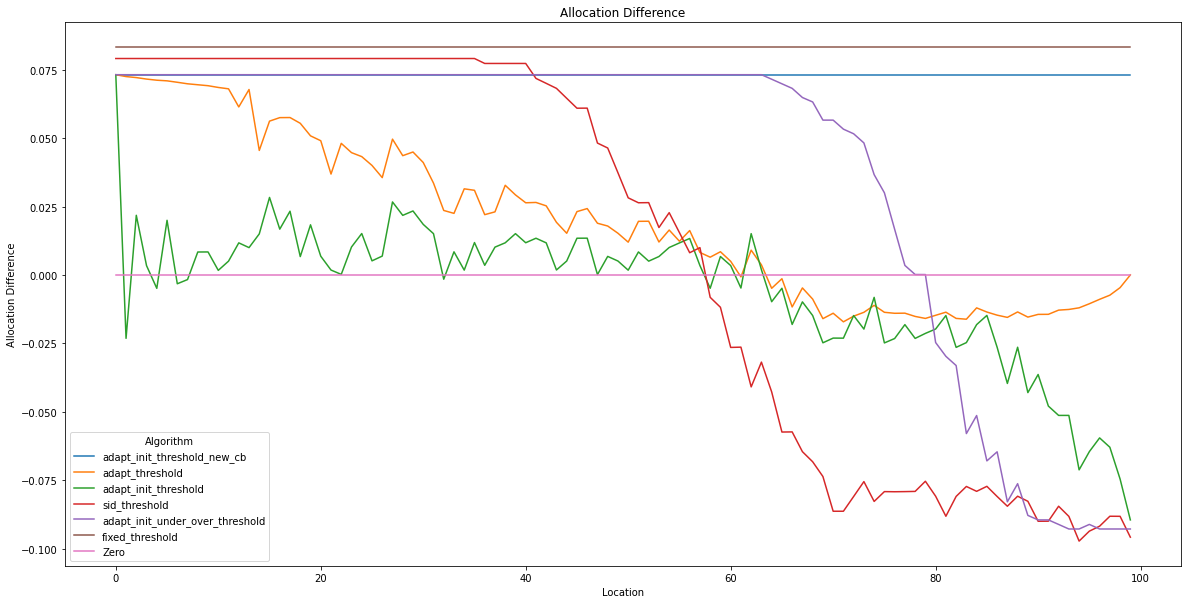

In [ ]:
df = pd.DataFrame.from_records(data)

plt.figure(figsize=(20,10))
sns.lineplot(x='Location', y='Value', hue = 'Algorithm', data=df, ci = None)
plt.title('Allocation Difference')
plt.xlabel('Location')
plt.ylabel('Allocation Difference')
plt.plot()

Note: Discrepancy is between where max and average are between this plot and the other one.